# Lab: Automate Credit Risk Assessment Test Case Generation from Jira Stories using Azure OpenAI

In this lab you will build a small **agent** that:

1. Connects to a Jira project and fetches a user story by key.
2. Extracts requirement-style information from the story (summary, description, and acceptance criteria).
3. Uses Azure OpenAI to generate structured test cases.

This notebook is a starting point for a training exercise. Valid Jira credentials, a Jira Cloud project, and an Azure OpenAI deployment are required.

## 1. Architecture Overview

High-level flow:

1. **Config and Secrets** - Configure the Jira URL, user email, API token, and Azure OpenAI settings. Keep secrets outside the code when possible.
2. **Jira Connector (Tool)** - A Python function `fetch_jira_issue(issue_key)` calls the Jira REST API.
3. **Requirement Extractor** - A function pulls the story summary, description, and acceptance criteria from the Jira issue JSON.
4. **Azure OpenAI Wrapper** - A client sends the extracted requirements to the configured Azure OpenAI deployment.
5. **Test Generation Agent** - The orchestrator fetches the story, extracts requirements, builds a prompt, calls Azure OpenAI, and returns test cases in Markdown.
6. **Export** - The Markdown table is converted to CSV and JSON.

The sample business workflow is **Automate Credit Risk Assessment for New Corporate Customers**. It verifies submitted documents, performs company and sanctions checks, calculates financial risk measures, retrieves external risk data, and recommends credit terms.

## Story details

**Summary**  
Automate Credit Risk Assessment for New Corporate Customers

**Issue Type**  
Story

**Description**

**User Story**  
As a credit analyst, I want the system to assess the credit risk of a new corporate customer using registration documents, financial information, external risk data, and industry risk so that I can assign an appropriate risk category, credit limit, and payment terms.

**Business Context**  
Credit analysts currently review corporate customer documents and financial information manually. This process is time-consuming, inconsistent, and difficult to audit. An automated assessment workflow will validate required evidence, identify compliance concerns, calculate transparent financial measures, combine internal and external risk signals, and provide a consistent recommendation for review.

---

### Functional Requirements

1. **Document Verification**
   - Verify that a Company Registration Certificate has been uploaded.
   - Verify that a GST Certificate has been uploaded.
   - Reject or flag the assessment when a required document is missing, unreadable, or invalid.

2. **Company and Compliance Checks**
   - Match the company name across the registration certificate, GST certificate, and customer record.
   - Verify the company's MCA status.
   - Perform sanctions screening and flag a potential match for analyst review.

3. **Financial Validation and Ratios**
   - Validate that two years of financial statements have been provided and are readable.
   - Calculate Current Ratio as current assets divided by current liabilities.
   - Calculate Debt-to-Equity Ratio as total debt divided by shareholders' equity.
   - Calculate Net Profit Margin as net profit divided by revenue.
   - Do not calculate a ratio when its denominator is zero or the financial input is invalid.

4. **Credit Risk Scorecard**
   - Calculate a final score out of 100 using these component weights:
     - Compliance: 20 points
     - Liquidity: 20 points
     - Leverage: 15 points
     - Profitability: 15 points
     - External Credit Bureau: 15 points
     - Industry Risk: 15 points
   - Use the following Current Ratio scoring thresholds for Liquidity:
     - Current Ratio >= 1.5: 20 points
     - Current Ratio 1.2-1.49: 15 points
     - Current Ratio 1.0-1.19: 8 points
     - Current Ratio < 1.0: 0 points
   - Use the following Debt-to-Equity scoring thresholds for Leverage:
     - Debt-to-Equity <= 0.5: 15 points
     - Debt-to-Equity 0.51-1.0: 12 points
     - Debt-to-Equity 1.01-2.0: 6 points
     - Debt-to-Equity > 2.0: 0 points
   - Use the following Net Profit Margin scoring thresholds for Profitability:
     - Net Profit Margin >= 15%: 15 points
     - Net Profit Margin 10%-14.99%: 12 points
     - Net Profit Margin 5%-9.99%: 6 points
     - Net Profit Margin < 5%: 0 points
   - Assign External Credit Bureau points from the D&B score:
     - D&B score >= 700: 15 points
     - D&B score 650-699: 10 points
     - D&B score 600-649: 5 points
     - D&B score < 600: 0 points
   - Assign Industry Risk points from this matrix:
     - Low Risk, 15 points: Utilities, Government, Healthcare
     - Medium Risk, 10 points: Manufacturing, FMCG Distribution, IT Services
     - High Risk, 0 points: Construction, Real Estate Developers, Airlines, Commodity Trading, Startups, Mining and Metal
   - Assign Compliance points according to the configured compliance policy when required documents, company-name matching, MCA status, and sanctions screening pass.

5. **Risk Classification Rules**
   - Score > 80: Low Risk
   - Score 50-80, inclusive: Medium Risk
   - Score < 50: High Risk
   - Apply the boundaries exactly as written, including scores of 50 and 80.

6. **Assessment and Recommendation**
   - Retrieve the customer's D&B score.
   - Determine the Industry Risk Rating using the industry risk matrix.
   - Calculate the final credit risk score from the configured document, compliance, financial, external, and industry inputs.
   - Assign a risk category based on the final score.
   - Recommend a credit limit and payment terms based on the risk category and assessment rules.
   - Store the assessment inputs, calculations, result, and recommendation for audit purposes.

---

### Non-Functional Requirements

1. A complete assessment must produce a result within 10 seconds when all required services respond normally.
2. The assessment must be deterministic and use the documented scorecard, calculation, threshold, and risk-category rules.
3. Sensitive customer and financial data must be protected in transit and at rest, and must not be written to application logs.
4. The workflow must provide clear validation errors and support analyst review for compliance or data-quality exceptions.
5. The assessment result and supporting calculations must be traceable for audit purposes.

---

### Acceptance Criteria

1. **Required Documents**
   - Given a new corporate customer assessment is started
   - When the Company Registration Certificate and GST Certificate are uploaded and valid
   - Then the assessment may continue to the next validation step.
   - When either required certificate is missing, unreadable, or invalid
   - Then the assessment must be flagged and must not produce a final recommendation.

2. **Company Name and MCA Validation**
   - Given valid registration and GST certificates
   - When the company names match and the MCA status is active
   - Then the company validation must pass.
   - When the names do not match or the MCA status is not active
   - Then the assessment must be flagged for review.

3. **Sanctions Screening**
   - Given a corporate customer is being assessed
   - When sanctions screening returns no potential match
   - Then the compliance check must pass.
   - When screening returns a potential match
   - Then the assessment must be flagged for analyst review and must not automatically approve credit terms.

4. **Financial Statements and Ratio Thresholds**
   - Given two years of valid financial statements
   - When the statements are processed
   - Then the system must calculate Current Ratio, Debt-to-Equity Ratio, and Net Profit Margin using the configured formulas.
   - Then the system must award Liquidity, Leverage, and Profitability points using the documented thresholds.
   - When statements are missing, unreadable, or contain invalid or zero denominators
   - Then the assessment must report a validation error and must not calculate an invalid ratio.

5. **Scorecard Component Boundaries**
   - Given valid assessment inputs
   - When a D&B score is 700, 650, 600, or just below one of those boundaries
   - Then the system must award 15, 10, 5, or 0 points according to the D&B thresholds.
   - When the customer belongs to an industry in the Low, Medium, or High matrix
   - Then the system must award the corresponding Industry Risk points.
   - The final score must equal the sum of Compliance, Liquidity, Leverage, Profitability, External Credit Bureau, and Industry Risk points, with a maximum of 100.

6. **Risk Classification and Recommendation**
   - Given a final score above 80, between 50 and 80 inclusive, or below 50
   - Then the system must assign Low Risk, Medium Risk, or High Risk respectively.
   - And it must recommend a credit limit and payment terms consistent with that category.
   - The assessment must retain the inputs, calculations, final score, category, and recommendation for audit.

7. **Response Time and Data Protection**
   - Given normal responses from dependencies
   - When a complete assessment is submitted
   - Then the result must be returned within 10 seconds.
   - Sensitive document contents and financial values must not appear in application logs.

## 2. Environment Setup

Run the installation cell once in a fresh environment. In a managed environment, skip packages that are already installed. The notebook targets Python 3.12.10 and uses `requests` for Jira and `openai` for Azure OpenAI.

In [ ]:
# If you are using a fresh Python 3.12.10 environment, run this cell once.
%pip install -q requests openai python-dotenv

## 3. Imports


In [ ]:
import getpass
import json
import os
from typing import Any, Dict

import requests

## 4. Jira Configuration

Before running the notebook, create a Jira Cloud account, create a Jira workspace, generate an API token, and create the Story that contains the credit-risk requirements.

### 4.1 Create a Jira Cloud Account

1. Go to [Atlassian account signup](https://id.atlassian.com/signup) and select **Sign up with Google**.

2. Complete the verification using the code sent to the Google account you used for signup.

3. Enter your **Full Name**, create a password, and select **Continue**.

4. From the left navigation, select **Jira Product Discovery**.

5. Select **Try it now**.

6. When prompted for a workspace name, enter a unique name.

7. Jira creates a workspace with a URL similar to:

   `https://<your-unique-name>.atlassian.net`

   This is your `JIRA_BASE_URL`.

8. Wait for the workspace setup to complete. This can take a few minutes.

Copy the workspace URL and remove any path after `.net`. For example:

```text
https://my-credit-lab.atlassian.net
```

Use this value for `JIRA_BASE_URL`.

### 4.2 Create a Jira API Token

1. Open the [Atlassian API token page](https://id.atlassian.com/manage-profile/security/api-tokens).
2. Complete the verification code sent to your Atlassian account email if prompted.
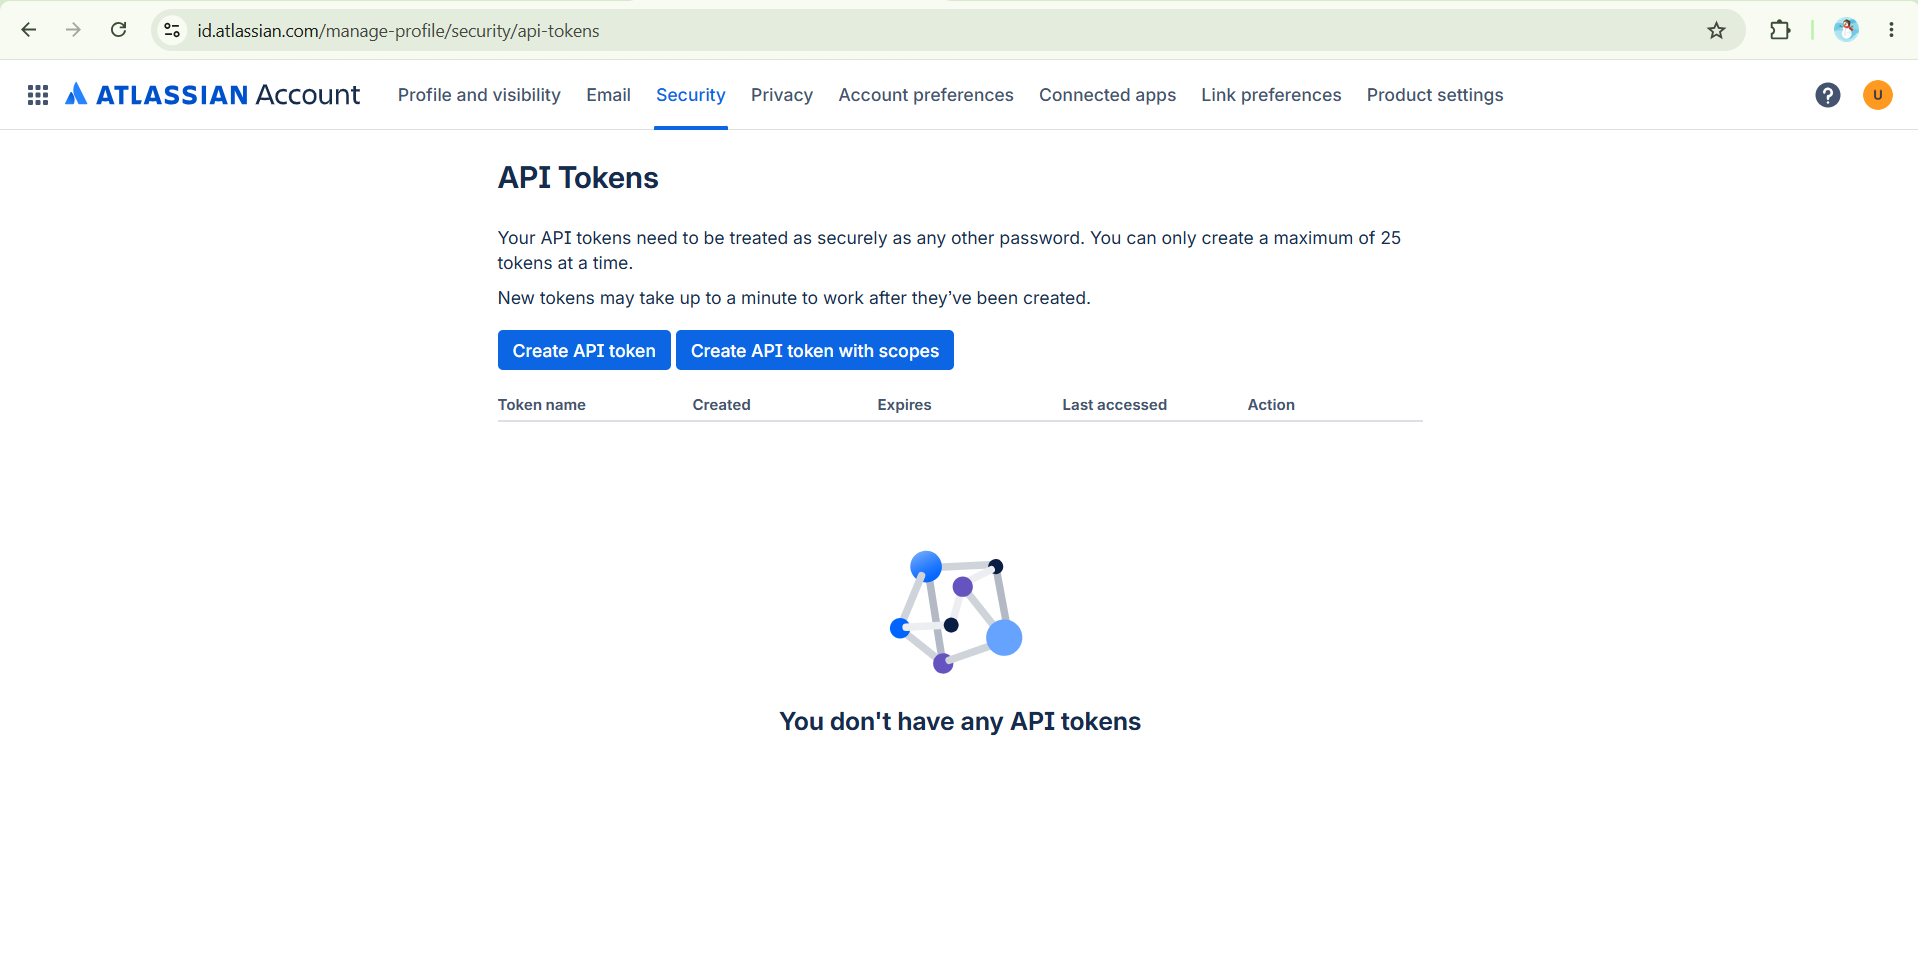
3. Select **Create API token**.
4. Enter a descriptive name for the token.
5. Set an expiration date according to your requirements.
6. Select **Create**.
7. Copy the generated API token and keep it secure.

> **Important:** The API token is displayed when it is created. Store it securely because it should not be committed to source control or shared with others.


### 4.3 Create a Jira Story

1. Open your Jira workspace by https://home.atlassian.com/
2. From the Jira navigation, select **Create**.
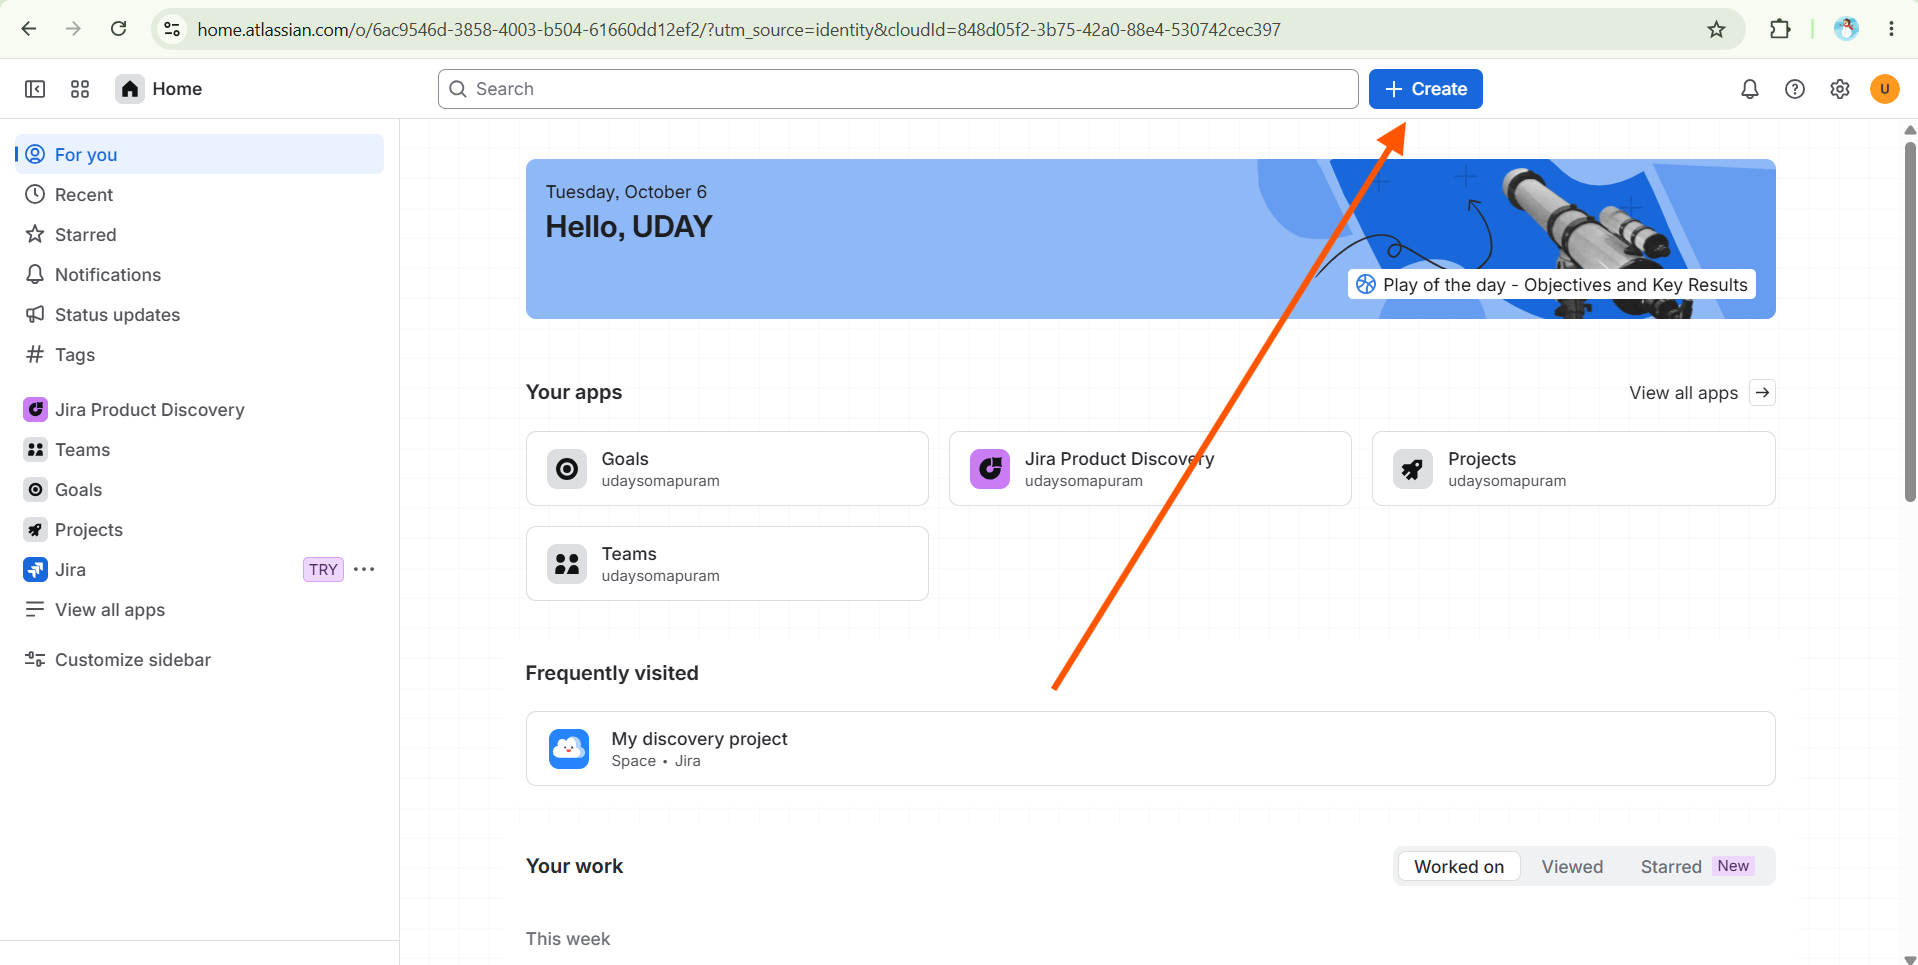
3. Leave **Space** at its default value.
4. In **Summary**, copy the **Summary** from [`Summary.txt`](https://github.com/Kiran-255666/AgenticAIEngineer/blob/main/labfiles/Day08/lab01-jira-openai-test-generation/Summary.txt).
5. In **Description**, copy the **Description** from [`Description.txt`](https://github.com/Kiran-255666/AgenticAIEngineer/blob/main/labfiles/Day08/lab01-jira-openai-test-generation/Description.txt).
6. Select **Create**.
7. After the Story is created, Jira displays a confirmation such as:

   `You've created "MDP-x" idea`

   The key, such as `MDP-x`, is the `ISSUE_KEY` required by the notebook.
8. Copy the Story key. You will use it as the `ISSUE_KEY` in the configuration section.

### 4.4 Configure Jira Values

The notebook reads Jira configuration from environment variables or accepts the values interactively. This avoids hard-coding credentials in the notebook.

The required values are:

| Variable         | Description                                       | Example                               |
| ---------------- | ------------------------------------------------- | ------------------------------------- |
| `JIRA_BASE_URL`  | Jira Cloud workspace URL                          | `https://my-credit-lab.atlassian.net` |
| `JIRA_EMAIL`     | Email address associated with the Jira account    | `user@example.com`                    |
| `JIRA_API_TOKEN` | API token generated from the Atlassian account    | `your-api-token`                      |
| `ISSUE_KEY`      | Key of the Jira Story containing the requirements | `MDP-x`                               |

You can set these values in your shell before starting Jupyter, or enter them interactively in the notebook.

Interactive values are kept in memory and are not written to a file.

> **Security:** Never commit your Jira API token or other credentials to source control.

### 4.5 Verify the Configuration

Before running the Jira connector, verify that:

* `JIRA_BASE_URL` contains only the Jira workspace URL and does not include `/jira/...` or another page path.
* `JIRA_EMAIL` matches the email address associated with your Jira account.
* `JIRA_API_TOKEN` contains the API token you generated.
* `ISSUE_KEY` contains the key of the Story you created, such as `MDP-x`.

In [ ]:
# --- Jira configuration ---
# NOTE: The values below are the pre-filled details.
# Please replace them with your own actual Jira details.
# We highly recommend following the steps above to obtain your own details.

os.environ.setdefault("JIRA_BASE_URL", "https://suday.atlassian.net")  # Replace with your own Jira base URL
os.environ.setdefault("JIRA_EMAIL", "sundayudiy007@gmail.com")  # Replace with your own Jira email
os.environ.setdefault("JIRA_API_TOKEN", "<replace_with_your_JIRA_API_TOKEN>")  # Replace with your own Jira API token
os.environ.setdefault("ISSUE_KEY", "MDP-7")  # Replace with your own Jira issue key


if not os.environ["JIRA_BASE_URL"]:
    os.environ["JIRA_BASE_URL"] = input("Enter your Jira base URL: ").strip().rstrip("/")
if not os.environ["JIRA_EMAIL"]:
    os.environ["JIRA_EMAIL"] = input("Enter your Jira email: ").strip()
if not os.environ["JIRA_API_TOKEN"]:
    os.environ["JIRA_API_TOKEN"] = getpass.getpass("Enter your Jira API token: ")

JIRA_BASE_URL = os.environ["JIRA_BASE_URL"].rstrip("/")
JIRA_EMAIL = os.environ["JIRA_EMAIL"]
JIRA_API_TOKEN = os.environ["JIRA_API_TOKEN"]
ISSUE_KEY = os.environ["ISSUE_KEY"]

In [ ]:
from openai import AzureOpenAI

# Set these values in the environment or replace the empty values before running this cell.
os.environ.setdefault("AZURE_OPENAI_ENDPOINT", "https://hakunamatata11.openai.azure.com/")
os.environ.setdefault("AZURE_OPENAI_API_KEY", "<your_OPENAI_API_KEY>") # TODO Replace with actual API KEY
os.environ.setdefault("AZURE_OPENAI_DEPLOYMENT_NAME", "gpt-5.4-mini")

AZURE_OPENAI_ENDPOINT = os.environ["AZURE_OPENAI_ENDPOINT"]
AZURE_OPENAI_API_KEY = os.environ["AZURE_OPENAI_API_KEY"]
AZURE_OPENAI_DEPLOYMENT_NAME = os.environ["AZURE_OPENAI_DEPLOYMENT_NAME"]

if not all((AZURE_OPENAI_ENDPOINT, AZURE_OPENAI_API_KEY, AZURE_OPENAI_DEPLOYMENT_NAME)):
    raise ValueError(
        "Set AZURE_OPENAI_ENDPOINT, AZURE_OPENAI_API_KEY, and "
        "AZURE_OPENAI_DEPLOYMENT_NAME before creating the Azure OpenAI client."
    )

# Verify the API version supported by your Azure OpenAI resource.
client = AzureOpenAI(
    api_key=AZURE_OPENAI_API_KEY,
    api_version="2025-01-01-preview",
    azure_endpoint=AZURE_OPENAI_ENDPOINT,
)

## 5. Jira Connector (Tool)

This helper calls the Jira Cloud v3 REST API and returns the issue JSON from `/rest/api/3/issue/{issueKey}`. The issue description contains the credit-risk requirements that will be sent to Azure OpenAI.

In [ ]:
def fetch_jira_issue(issue_key: str) -> Dict[str, Any]:
    """Fetch a Jira issue by key and return the JSON response."""
    if not issue_key:
        raise ValueError("Set ISSUE_KEY to a Jira story key before fetching an issue.")

    url = f"{JIRA_BASE_URL}/rest/api/3/issue/{issue_key}"
    auth = (JIRA_EMAIL, JIRA_API_TOKEN)
    response = requests.get(url, auth=auth, timeout=30)

    try:
        response.raise_for_status()
    except requests.HTTPError as error:
        print("Error while calling Jira:", error)
        print("Response text:", response.text[:1000])
        raise

    return response.json()


# Optional smoke test. Set ISSUE_KEY before running this cell.
if ISSUE_KEY:
    test_issue = fetch_jira_issue(ISSUE_KEY)
    issue_type = test_issue.get("fields", {}).get("issuetype", {}).get("name")
    print(f"Fetched issue {ISSUE_KEY}. Issue type: {issue_type}")
else:
    print("Set ISSUE_KEY to run the Jira smoke test.")

## 6. Requirement Extractor

Jira fields can contain plain text or rich-text JSON. This lab will:

- Always extract `summary`.
- Convert `description` and other fields to readable strings.
- Preserve the full credit-risk workflow, including functional requirements, non-functional requirements, and acceptance criteria written in the story description.
- Optionally extract acceptance criteria from a custom field when the Jira project stores them separately.

In [ ]:
def normalize_field(field_value: Any) -> str:
    """Convert a Jira field, including nested rich text, into a prompt-friendly string."""
    if field_value is None:
        return ""
    if isinstance(field_value, str):
        return field_value
    return json.dumps(field_value, indent=2, ensure_ascii=False)


def extract_requirements(issue_json: Dict[str, Any]) -> Dict[str, str]:
    """Extract the story summary, description, and optional acceptance criteria."""
    fields = issue_json.get("fields", {})
    acceptance_criteria = fields.get("customfield_acceptance_criteria", "")

    return {
        "summary": normalize_field(fields.get("summary", "")),
        "description": normalize_field(fields.get("description", "")),
        "acceptance_criteria": normalize_field(acceptance_criteria), # Replace with your Jira custom field ID if acceptance criteria are stored separately from the story description.
    }

# Example preview after the Jira connector has fetched an issue.
if "test_issue" in globals():
    reqs_preview = extract_requirements(test_issue)
    print("Summary:\n", reqs_preview["summary"], "\n")
    print("Description (truncated):\n", reqs_preview["description"][:500], "\n")

#### Extract functional requirements, non-functional requirements, and acceptance criteria from the Jira story description

In [ ]:
def extract_story_requirements(requirements: Dict[str, str]) -> str:
    """Use Azure OpenAI to organize the Jira description into requirement sections."""

    response = client.chat.completions.create(
        model=AZURE_OPENAI_DEPLOYMENT_NAME,
        messages=[
            {
                "role": "system",
                "content": (
                    "Extract and organize the functional requirements, non-functional "
                    "requirements, and acceptance criteria from this Jira story. "
                    "Preserve all credit-risk steps, formulas, scorecard weights, "
                    "thresholds, industry matrix values, validations, and outcomes."
                ),
            },
            {
                "role": "user",
                "content": (
                    f"Summary:\n{requirements['summary']}\n\n"
                    f"Description:\n{requirements['description']}\n\n"
                    f"Acceptance criteria field:\n{requirements['acceptance_criteria']}"
                ),
            },
        ],
        max_completion_tokens=2000,
    )

    return response.choices[0].message.content or ""


if "reqs_preview" in globals():
    organized_requirements = extract_story_requirements(reqs_preview)
else:
    organized_requirements = ""
    print(
        "Run the Jira connector and requirement extractor first "
        "to organize the requirements."
    )

In [ ]:
if organized_requirements:
    print(organized_requirements)
else:
    print("No organized requirements are available. Run the preceding cells after configuring Jira and Azure OpenAI.")

## 7. Prompt Setup

The lab uses the Azure OpenAI deployment configured in `AZURE_OPENAI_DEPLOYMENT_NAME`. The deployment should support structured, detailed responses suitable for generating test cases.

In [ ]:
system_prompt = """
You are a senior QA engineer.

Create comprehensive, high-quality test cases for the Jira story provided by the user.

Use all of the following inputs:
- Functional requirements
- Non-functional requirements
- Acceptance criteria

For the credit-risk workflow, cover document upload and validation, company-name matching,
MCA status, sanctions screening, financial statements, ratio calculations, D&B score,
industry risk, final score, risk category, credit limit, payment terms, auditability,
performance, data protection, and analyst review exceptions.

Use the scorecard and thresholds exactly as provided. Do not invent alternative scoring logic:
- Compliance 20, Liquidity 20, Leverage 15, Profitability 15, External Credit Bureau 15, Industry Risk 15.
- Score > 80 is Low Risk, 50-80 inclusive is Medium Risk, and < 50 is High Risk.
- Test every stated ratio, D&B, industry, and risk-category boundary.

Follow these guidelines:
1. Cover positive, negative, error-handling, security, performance, and boundary scenarios.
2. Verify the formulas and invalid-denominator behavior for all financial ratios.
3. Ensure each test case maps to at least one requirement or acceptance criterion.
4. Avoid duplicate cases and use concise wording suitable for a test management tool.
5. Include preconditions, steps, expected results, mapped requirements, and priority.
6. Do not use the pipe character (|) inside Markdown table cell content. Use commas, semicolons, or words instead.
"""

## 8. Prompt Engineering for Test Generation

The model will act as a senior QA engineer and output test cases in a Markdown table.

Columns:

- `ID`
- `Title`
- `Type (Positive/Negative/Edge)`
- `Pre-conditions`
- `Steps`
- `Expected Result`
- `Mapped Requirement(s)`
- `Priority`

The generated cases should include examples for missing or invalid certificates, company-name mismatches, inactive MCA status, sanctions matches, invalid financial statements, zero denominators, ratio threshold boundaries, D&B score thresholds, industry matrix categories, final-score boundaries, credit-limit recommendations, payment terms, audit records, response time, and sensitive-data logging.

Do not use the pipe character `|` inside Markdown table cell content. Use commas, semicolons, or words instead so the export parser can preserve each cell.

Example output shape:

| ID | Title | Type (Positive/Negative/Edge) | Pre-conditions | Steps | Expected Result | Mapped Requirement(s) | Priority |
|---|---|---|---|---|---|---|---|
| TC-001 | Validate required certificates | Positive | Valid company record and readable certificates | Upload the Company Registration Certificate and GST Certificate; submit the assessment | Both documents are accepted and the assessment continues | Document Verification; AC-1 | High |
| TC-002 | Reject zero current liabilities | Negative | Financial statements contain zero current liabilities | Submit the statements for assessment | The Current Ratio is not calculated; a validation error is reported | Financial Validation and Ratios; AC-4 | High |
| TC-003 | Review sanctions potential match | Edge | Screening service returns a potential match | Submit the customer for sanctions screening | The assessment is flagged for analyst review and no automatic credit terms are approved | Sanctions Screening; AC-3 | High |

In [ ]:
TESTGEN_PROMPT = """
Story summary:
{summary}

Story requirements (functional, non-functional, and acceptance criteria):
{requirements_text}

Produce a complete set of test cases in a Markdown table with these columns:

| ID | Title | Type (Positive/Negative/Edge) | Pre-conditions | Steps | Expected Result | Mapped Requirement(s) | Priority |

Number the IDs as TC-001, TC-002, and so on. Cover the full credit-risk workflow:
required certificates, company-name matching, MCA status, sanctions screening, two years
of financial statements, Current Ratio, Debt-to-Equity Ratio, Net Profit Margin, D&B score,
Industry Risk Rating, final score, risk category, credit limit, payment terms, auditability,
performance, data protection, and analyst review exceptions.

Use the scorecard weights and thresholds exactly as supplied. Include boundary tests for
ratio bands, D&B scores of 700, 650, and 600, every industry matrix category, and final
scores of 49, 50, 80, and 81. Do not invent scoring logic. Do not use the pipe character
(|) inside any Markdown table cell; use commas, semicolons, or words instead.

Ground every test case in the supplied requirements and acceptance criteria.
"""


def build_testcase_prompt(summary: str, requirements_text: str) -> str:
    return TESTGEN_PROMPT.format(
        summary=summary,
        requirements_text=requirements_text,
    )

## 9. Putting It Together: The Test Generation Agent

The agent is a simple orchestrator that:

1. Fetches the Jira story.
2. Extracts the summary, description, and optional acceptance criteria.
3. Organizes the requirements with Azure OpenAI.
4. Builds the test-generation prompt.
5. Calls Azure OpenAI and returns the generated test cases in Markdown.

In [ ]:
def generate_with_llm(prompt: str, max_tokens: int = 2500) -> str:
    """Generate Markdown test cases with the configured Azure OpenAI deployment."""

    response = client.chat.completions.create(
        model=AZURE_OPENAI_DEPLOYMENT_NAME,
        messages=[
            {
                "role": "system",
                "content": (
                    "You are a software testing assistant. "
                    "Generate clear, complete, and structured test cases "
                    "from the provided Jira requirements. "
                    "Return the test cases in Markdown format."
                ),
            },
            {
                "role": "user",
                "content": prompt,
            },
        ],
        max_completion_tokens=max_tokens,
    )

    return response.choices[0].message.content or ""

In [ ]:
class JiraTestGenerationAgent:
    def __init__(self, issue_key: str):
        self.issue_key = issue_key

    def run(self) -> str:
        issue_json = fetch_jira_issue(self.issue_key)
        requirements = extract_requirements(issue_json)
        organized_requirements = extract_story_requirements(requirements)
        requirements_text = organized_requirements or requirements["description"]
        prompt = build_testcase_prompt(requirements["summary"], requirements_text)

        print("Prompt sent to Azure OpenAI (truncated):")
        print(prompt[:1000], "...\n")

        output = generate_with_llm(prompt)
        print("Generated test cases:\n")
        print(output)
        return output

## 10. Run the Agent on a Jira Story

Set `ISSUE_KEY` to the Jira story for **Automate Credit Risk Assessment for New Corporate Customers**, for example `CREDIT-101`, then run the cell. The notebook must already have valid Jira and Azure OpenAI configuration.

In [ ]:
ISSUE_KEY = os.environ.get("ISSUE_KEY", "")

if not ISSUE_KEY:
    ISSUE_KEY = input("Enter the Jira issue key for the credit-risk story: ").strip()

agent = JiraTestGenerationAgent(issue_key=ISSUE_KEY)
testcases_markdown = agent.run()

In [ ]:
import csv
import json

if "testcases_markdown" not in globals() or not testcases_markdown:
    raise ValueError("Run the agent cell first so generated test cases are available to export.")

# ---------- 1. Parse Markdown table into rows ----------

lines = [line.strip() for line in testcases_markdown.splitlines()]
table_lines = [
    line for line in lines
    if "|" in line and not set(line.replace("|", "").replace("-", "").replace(":", "").strip()) == set()
]

if len(table_lines) < 2:
    raise ValueError("No Markdown test-case table was found in testcases_markdown.")

headers = [cell.strip() for cell in table_lines[0].strip("|").split("|")]
rows = []

for row_line in table_lines[1:]:
    cells = [cell.strip() for cell in row_line.strip("|").split("|")]
    if len(cells) < len(headers):
        cells.extend([""] * (len(headers) - len(cells)))
    row_dict = dict(zip(headers, cells[:len(headers)]))
    rows.append(row_dict)

print(f"Parsed {len(rows)} test cases with columns: {headers}")

# ---------- 2. Save as CSV ----------

csv_filename = f"{ISSUE_KEY}_credit_risk_testcases.csv"
with open(csv_filename, "w", newline="", encoding="utf-8") as csvfile:
    writer = csv.DictWriter(csvfile, fieldnames=headers)
    writer.writeheader()
    writer.writerows(rows)

print(f"CSV saved to {csv_filename}")

# ---------- 3. Save as JSON ----------

json_filename = f"{ISSUE_KEY}_credit_risk_testcases.json"
with open(json_filename, "w", encoding="utf-8") as jsonfile:
    json.dump(rows, jsonfile, ensure_ascii=False, indent=2)

print(f"JSON saved to {json_filename}")

## 11. Extensions & Next Steps

If you finish the lab early, we highly recommend exploring the following optional hands-on extensions to deepen your understanding and get more practice with the solution:

* **Code-Change Driven Tests**
  Instead of, or in addition to, Jira Stories, try parsing Git diffs and providing the changed functions or classes to the LLM to generate relevant test cases.

* **Save Results Back to Jira**
  Extend the Jira integration to post the generated test cases back to the Story as a comment or attach them as a file using the Jira REST API.

* **Stronger Parsing**
  Improve the requirement extraction by parsing Jira rich-text descriptions and structured acceptance criteria more carefully instead of relying on simple JSON extraction.

* **Multi-Agent Setup**
  Split the workflow into multiple agents, with each agent handling a specific task:

  * **Requirements Agent** – Cleans and normalizes the Story requirements.
  * **Test Designer Agent** – Generates test cases from the requirements.
  * **Reviewer Agent** – Reviews the generated test cases and identifies missing coverage.

These extensions are optional, but completing them is highly recommended if you have additional time.

## Lab Summary

In this lab, you built an agent that connects to Jira, retrieves a credit-risk user story, extracts its requirements, and uses Azure OpenAI to generate structured test cases.

You worked through the complete flow:

* Configured Jira Cloud and Azure OpenAI.
* Created and retrieved a Jira Story using the Jira REST API.
* Extracted the Story summary, description, and acceptance criteria.
* Used Azure OpenAI to organize requirements and generate test cases.
* Designed prompts to cover functional, negative, edge, security, and performance scenarios.
* Exported the generated test cases to CSV and JSON.

By completing this lab, you have a starting point for automating requirement-based test case generation using Jira and Azure OpenAI.